# HANNAN MAZHAR 23-NTU-CS-1035

# Machine Learning Lab 2 - Activities


## Activity 1: Medical Insurance Cost Prediction
Predict a person's medical insurance cost (Linear Regression)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

In [26]:
# Load Dataset
data = pd.read_csv("Medical Cost Personal Datasets.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
# Check for missing values
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [28]:
# Encode categorical features
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex'])        # male=1, female=0
data['smoker'] = le.fit_transform(data['smoker'])  # yes=1, no=0

# One-Hot Encoding for region
data = pd.get_dummies(data, columns=['region'])
data.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [29]:
# Features and target
y = data['charges']
X = data.drop('charges', axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [31]:
# Calculating RMSE
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

# Calculating R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 5796.284659276274
R2 Score: 0.7835929767120722


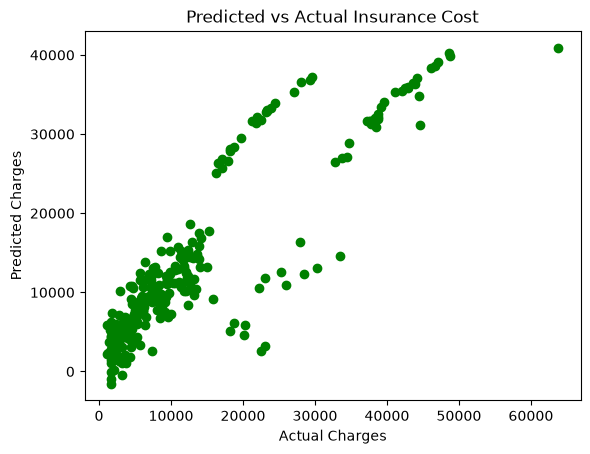

In [32]:
# Plot Predicted vs Actual Costs
plt.scatter(y_test, y_pred, color='green', label='Predicted vs Actual')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Predicted vs Actual Insurance Cost')
plt.show()

## Activity 2: Telco Customer Churn Prediction
Predict whether a customer will churn (Logistic Regression)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve

In [34]:
# Load dataset
data = pd.read_csv("Telco Customer Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
# Encode target (Churn: Yes/No -> 1/0)
le = LabelEncoder()
data['Churn'] = le.fit_transform(data['Churn'])

# One-Hot Encoding for categorical features
data = pd.get_dummies(data, columns=['Contract', 'InternetService'])

In [36]:
# Features & target
feature_cols = ['tenure', 'MonthlyCharges'] + [c for c in data.columns if c.startswith('Contract_') or c.startswith('InternetService_')]
X = data[feature_cols].values
y = data['Churn'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8026969481902059
Confusion Matrix:
 [[934 102]
 [176 197]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



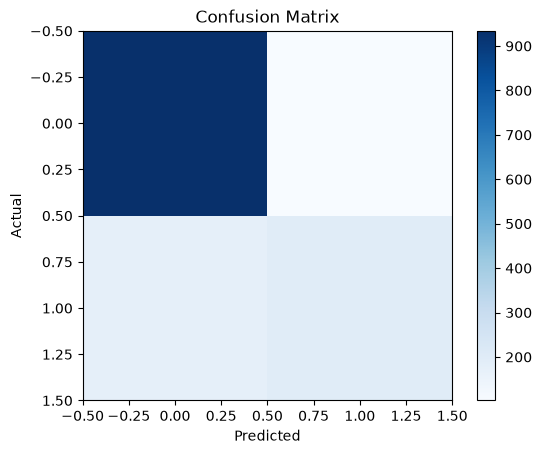

In [38]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

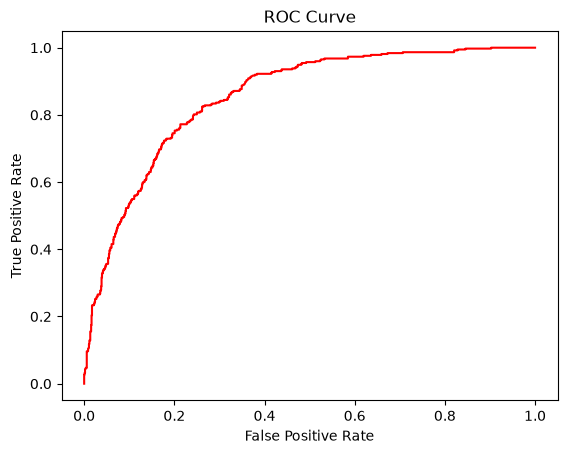

In [39]:
# Plot ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='red', label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## Activity 3: Car Price Prediction
Predict used car prices (Linear Regression vs Polynomial Regression)

In [40]:
# Load dataset
data = pd.read_csv("Car Price Prediction.csv")
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [41]:
# Feature (Horsepower) and target (Price)
X = data[["horsepower"]].values
y = data["price"].values

Linear Regression -> RMSE: 4693.880026407783  R2: 0.653088356490231


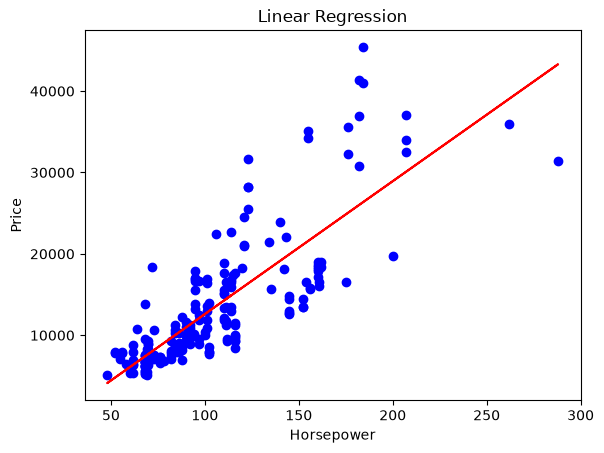

In [42]:
# Linear Regression
lr = LinearRegression()
lr.fit(X, y)
y_pred_lr = lr.predict(X)

rmse_lr = root_mean_squared_error(y, y_pred_lr)
r2_lr = r2_score(y, y_pred_lr)
print("Linear Regression -> RMSE:", rmse_lr, " R2:", r2_lr)

plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, y_pred_lr, color="red", label="Linear Fit")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.title("Linear Regression")
plt.show()

Polynomial Regression (degree=2) -> RMSE: 4685.81  R2: 0.6543


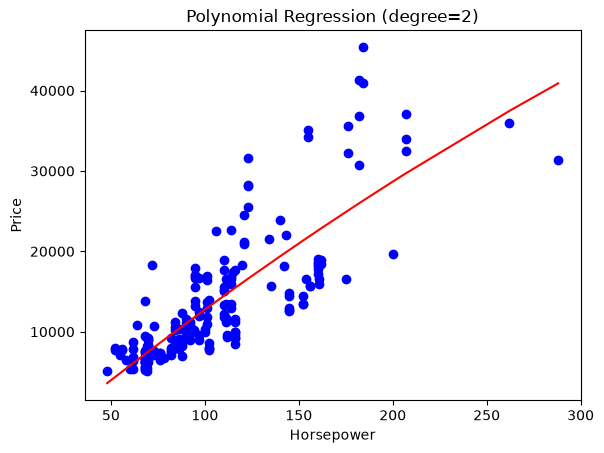

Polynomial Regression (degree=3) -> RMSE: 4577.47  R2: 0.6701


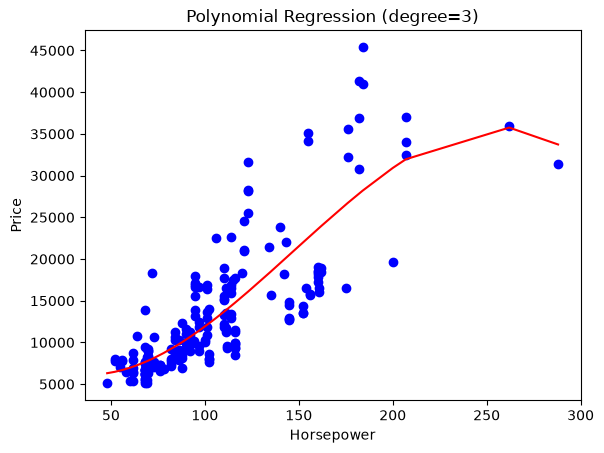

Polynomial Regression (degree=4) -> RMSE: 4566.52  R2: 0.6717


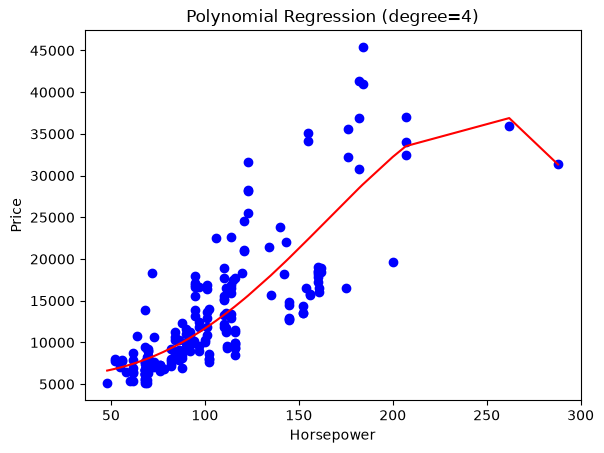

In [43]:
from sklearn.preprocessing import PolynomialFeatures
# Polynomial Regression - degree 2, 3, 4
for degree in [2, 3, 4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)
    y_pred_poly = poly_model.predict(X_poly)

    rmse_poly = root_mean_squared_error(y, y_pred_poly)
    r2_poly = r2_score(y, y_pred_poly)
    print("Polynomial Regression (degree=%d) -> RMSE: %.2f  R2: %.4f" % (degree, rmse_poly, r2_poly))

    # sort values so the fitted curve is smooth
    sort_idx = np.argsort(X[:, 0])
    X_sorted = X[sort_idx]
    y_pred_sorted = y_pred_poly[sort_idx]

    plt.scatter(X, y, color="blue", label="Actual Data")
    plt.plot(X_sorted, y_pred_sorted, color="red", label="Polynomial Fit (deg=%d)" % degree)
    plt.xlabel("Horsepower")
    plt.ylabel("Price")
    plt.title("Polynomial Regression (degree=%d)" % degree)
    plt.show()